In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install IPython
%pip install tabulate
%pip install networkx
#instalo las librerias

You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.



Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
%pip install scikit-learn pandas --user

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import tabulate
import networkx as nx
from random import random as rand
import itertools
from sklearn.preprocessing import LabelEncoder
#importo las librerias

In [23]:
def sigmoid(x):
    return 1 / ( 1 + np.exp(-x) )

# sigmoid = lambda x : 1 / ( 1 + np.exp(-x) )

def sigmoid_derivative(x):
    return x * (1 - x)

# sigmoid_derivative = lambda x : x * (1 - x)

#se crea la función de activación sigmoide, esta sirve para clasificación binaria que devuelve valores entre 1 y 0

In [4]:
ds= pd.read_csv("full.csv")
col_names = ds.columns
col_names
#lee el dataset y muestra sus columnas

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'WikiId', 'Name_wiki',
       'Age_wiki', 'Hometown', 'Boarded', 'Destination', 'Lifeboat', 'Body',
       'Class'],
      dtype='object')

In [81]:
ds = ds.fillna(0)  #rellena los valores nan con cero
le= LabelEncoder()
ds["Sex"] = le.fit_transform(ds["Sex"]) #pasa los valores mujer y hombre a numérico: 1 y 0
training_inputs = ds[["Sex", "Pclass", "Age"]].values #declara que se toma en cuenta para realizar la predicción, define los que recibe en la capa de entrada
training_outputs = ds["Survived"].values.reshape(-1,1)# define lo que se va a predecir

display(training_inputs)#indica que se muestren los training inputs
display(training_outputs)#indica que se muestren los training outputs

array([[ 1. ,  3. , 22. ],
       [ 0. ,  1. , 38. ],
       [ 0. ,  3. , 26. ],
       ...,
       [ 1. ,  3. , 38.5],
       [ 1. ,  3. ,  0. ],
       [ 1. ,  3. ,  0. ]])

array([[0.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [0.]])

In [31]:
training_values = np.concatenate((training_inputs.T, training_outputs.T)).T   #combina los training inputs y outpust en un array
table = lambda arr : display(HTML(tabulate.tabulate(arr, tablefmt='html'))) # toma el array como input
table(training_values) #llama a la función y la muestra

1,3,0
0,1,1
0,3,1
0,1,1
1,3,0
1,3,0
1,1,0
1,3,0
0,3,1
0,2,1
0,3,1


In [82]:
print(training_inputs.shape)  #muestra las dimensiones de training inputs en formato (filas, columnas)

(1309, 3)


In [8]:
print(training_outputs.shape) ##muestra las dimensiones de training outputs en formato (filas, columnas)

(1309, 1)


In [83]:
m = training_inputs.shape[1] #agarra la cantidad de columnas de training inputs
synaptic_weights = np.random.random((m, 1)) # arma un array para los synaptic weights para la red neuronal, se llena con números random entre cero y uno

synaptic_weights 

array([[0.74382636],
       [0.55386761],
       [0.7870641 ]])

In [84]:
forward = lambda x, w:(np.dot(x, w)) #define la función para calcular la salida 

In [86]:
input_layer = training_inputs #asigna los training inputs a la input layer
input_layer = np.nan_to_num(input_layer, 0) # llena los valores nan con 0


outputs = forward(input_layer, synaptic_weights)  #calcula la salida en base a la input layer y los synaptic weights

outputs

array([[19.72083929],
       [30.46230322],
       [22.12526931],
       ...,
       [32.70739685],
       [ 2.4054292 ],
       [ 2.4054292 ]])

In [1]:
input_layer.shape #muestra las dimensiones de la capa de entrada 

NameError: name 'input_layer' is not defined

In [87]:
training_outputs 

array([[0.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [0.]])

In [88]:
# Calculo el error
error = training_outputs - outputs
error

array([[-19.72083929],
       [-29.46230322],
       [-21.12526931],
       ...,
       [-32.70739685],
       [ -2.4054292 ],
       [ -2.4054292 ]])

In [90]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
t_i = np.array(scaler.fit_transform(training_inputs))
t_i
# estandariza los training inputs

array([[ 0.74349692,  0.84191642, -0.10677343],
       [-1.34499549, -1.54609786,  0.80313826],
       [-1.34499549,  0.84191642,  0.12070449],
       ...,
       [ 0.74349692,  0.84191642,  0.831573  ],
       [ 0.74349692,  0.84191642, -1.35790199],
       [ 0.74349692,  0.84191642, -1.35790199]])

In [95]:
epochs = 4  #define la cantidad de veces que la training data va a pasar por la red

synaptic_weights = np.random.random((m, 1))

for iteration in range(epochs):

    # Arranca con los valores de training
    input_layer = t_i # asigna los valores estandarizados de training inputs a la input layer
    input_layer = np.nan_to_num(input_layer, 0) # llena los valores nan con 0

    # Genera un output haciendo la suma de los valores de input multiplicados por su peso sinaptico, y aplicandole la función sigmoide para normalizar a -1, 1
    outputs = forward(input_layer, synaptic_weights)
    print(outputs)
    # Calcula el error
    error = training_outputs - outputs

    # Ajusta los pesos en funcion al error y al resultado obtenido
    adjustments = error * sigmoid_derivative(outputs)
    synaptic_weights += np.dot(input_layer.T, adjustments)

[[ 0.79024123]
 [-1.35834102]
 [-0.68079964]
 ...
 [ 0.91116434]
 [ 0.62901042]
 [ 0.62901042]]
[[ 2814.7658149 ]
 [-5178.8599763 ]
 [-1897.44543592]
 ...
 [ 2728.88477018]
 [ 2929.27387452]
 [ 2929.27387452]]
[[ 6.80419490e+13]
 [-1.34626228e+14]
 [-2.61019749e+13]
 ...
 [ 5.17295963e+13]
 [ 8.97917525e+13]
 [ 8.97917525e+13]]
[[ 1.17570675e+45]
 [-2.47393346e+45]
 [-3.34585269e+44]
 ...
 [ 6.68108194e+44]
 [ 1.85250482e+45]
 [ 1.85250482e+45]]


In [96]:
#muestra los synaptic weights y outputs después de que se complete el proceso de entrenamiento
print('Synaptic weights after training')
print(synaptic_weights)

print('Outputs after training: ')
print(outputs)

Synaptic weights after training
[[ 4.10652989e+138]
 [ 5.18917659e+138]
 [-4.81097390e+138]]
Outputs after training: 
[[ 1.17570675e+45]
 [-2.47393346e+45]
 [-3.34585269e+44]
 ...
 [ 6.68108194e+44]
 [ 1.85250482e+45]
 [ 1.85250482e+45]]


In [97]:
table(training_values) #muestra cuantas veces aparece cada valor en el conjunto de training values

1,3,0
0,1,1
0,3,1
0,1,1
1,3,0
1,3,0
1,1,0
1,3,0
0,3,1
0,2,1
0,3,1


In [98]:
large = lambda x : display(HTML('<p style="font-size: 50px; color: #66D148">'+str(x)+'</p>')) 

In [102]:
#define los parámetros
a = 1 #@param {type:"integer"}
c = 2 #@param {type:"integer"}
b = 3 #@param {type:"integer"}
#crea un array que representa la input data para la red  con los parámetros de antes
input_layer = np.array([a, b, c])
#matrix multiplication entre input layer y synaptic weights 
res = np.dot(input_layer, synaptic_weights)[0]
display(res)
#hace que, si res es menor a 0.01, el resultado de la predicción sea 0, si esto no se cumple, que sea 1
thresh = 0.01
out = 0 if res < thresh else 1

large(out) #muestra la predicción

np.float64(1.0052111869194702e+139)

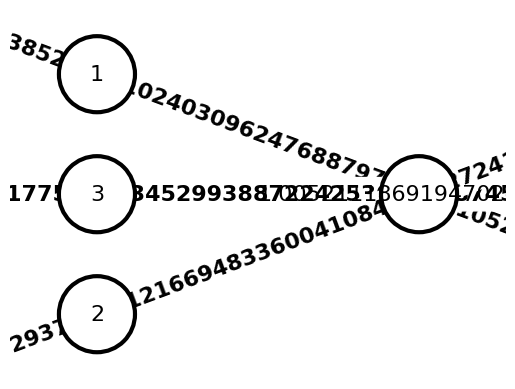

In [103]:
#crea el gráfico
G = nx.DiGraph()
#define las capas
layers = [[0, 1, 2], [3]]
#crea una lista de las posibles conexiones entre las capas
rels = list(itertools.product(*layers))
#rels.append((3, 4))
# función que mete todo en una sola lista
flatten = lambda l: [x for i in l for x in i]
#asocia los input values y el resultado en una tabla
labels = {i: v for i, v in enumerate(input_layer)}
labels[3] = round(res, 3)
#labels[4] = 0 if res < thresh else 1

pos = {}
m = max([len(l) for l in layers])
for i, l in enumerate(layers):
  for j, v in enumerate(l):
    pos[v] = (i, len(l) - j)

pos[3] = (pos[3][0], pos[1][1])
#pos[4] = (pos[3][0] + 1, pos[1][1])

weights_labels = {(ra, rb): "{:0.3f}".format(synaptic_weights[i][0]) for i, (ra, rb) in enumerate(rels)}
G.add_edges_from(rels)

options = {
    "font_size": 16,
    "node_size": 3000,
    "node_color": [(1, 1, 1, 1) for _ in range(len(labels))],
    "edgecolors": "black",
    "linewidths": 3,
    "width": 3,
    "labels": labels,
    "connectionstyle": "arc3, rad=0",
}

nx.draw_networkx(G, pos, **options)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=weights_labels,
    font_color='black',
    font_size=16, 
    font_weight='bold'
)

plt.axis('off')
ax = plt.gca()
ax.margins(0.20)
plt.show()